In [64]:
from file_utils import concat_txt_files_with_labels

concat_txt_files_with_labels(
    [
        "./output/comparison/组合数据/ds无检索3指标_metrics.txt",
        "./output/comparison/组合数据/ds向量检索3指标_metrics.txt",
        "./output/comparison/组合数据/ds图检索3指标_metrics.txt",
    ],
    './output/comparison/组合数据/ds3指标.txt',
    labels=['ds无检索', 'ds向量检索', 'ds图检索'],
    has_header=False
)


合并完成：
  [ds无检索] ./output/comparison/组合数据/ds无检索3指标_metrics.txt: 267 条
  [ds向量检索] ./output/comparison/组合数据/ds向量检索3指标_metrics.txt: 300 条
  [ds图检索] ./output/comparison/组合数据/ds图检索3指标_metrics.txt: 145 条
总计 712 行，保存至 ./output/comparison/组合数据/ds3指标.txt


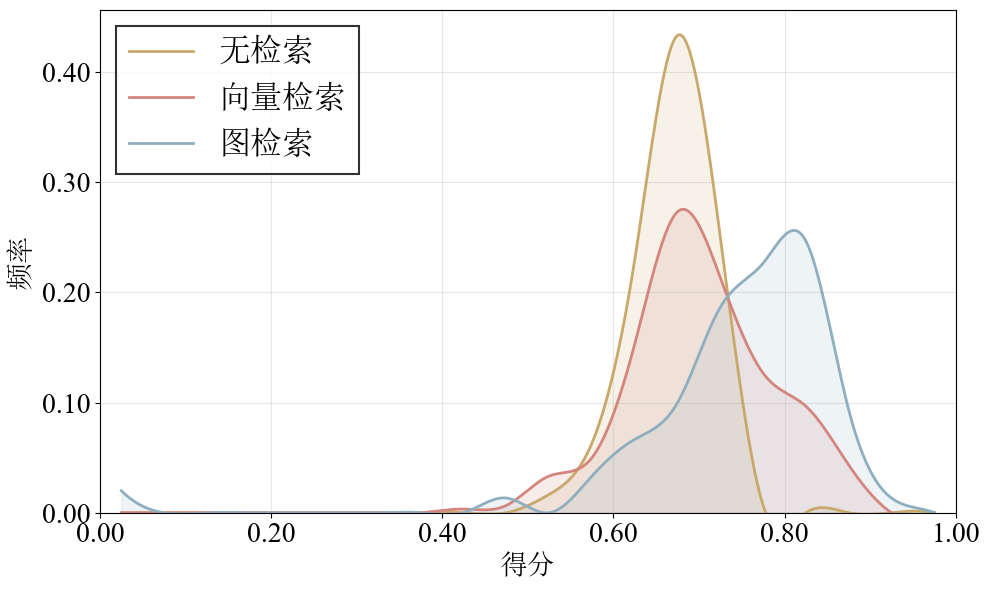

In [104]:
# -*- coding: utf-8 -*-
# 核密度图绘制（平滑KDE版）
# 输入：;分割的txt文件，第一列为分组标签，倒数第3/2/1字段分别为知识相关性、可解释性、难度准确性
# 输出：指定指标的三组平滑核密度曲线

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde   # 新增导入
import matplotlib.ticker as ticker

plt.rcParams["font.family"] = ["Times New Roman", "SimSun", "sans-serif"]


# ===================== 配置 =====================
INPUT_FILE = r"C:/Users/lenovo/LLM/thesis/geograph/output/comparison/组合数据/qwen3指标.txt"

METRIC = "relevance"   # 可改为 "relevance" "explainability" "accuracy"

LEGEND_MAP = {
    "无检索":   "无检索",
    "向量检索": "向量检索",
    "图检索":  "图检索",
}

COLORS = ["#C8A96B", "#D4867E", "#8FAFC0"]

# ===================== 读取数据 =====================
df = pd.read_csv(INPUT_FILE, sep=";", header=None, dtype=str)

metric_col_map = {
    "relevance":     -3,
    "explainability": -2,
    "accuracy":      -1,
}
col_idx = metric_col_map[METRIC]

mask_valid = df.iloc[:, col_idx].apply(lambda x: str(x).replace(".", "").isdigit() if pd.notna(x) else False)
df_clean = df[mask_valid]
metric_data = pd.to_numeric(df_clean.iloc[:, col_idx], errors="coerce")
labels_valid = df_clean.iloc[:, 0]

metric_name_map = {"relevance": "知识相关性", "explainability": "可解释性", "accuracy": "难度准确性"}

# 按分组提取数据
groups = {}
for label in labels_valid.unique():
    mask = labels_valid == label
    values = metric_data[mask.values].values
    if len(values) > 0:
        groups[label] = values

# ===================== 绘图（平滑KDE） =====================
from scipy.interpolate import make_interp_spline   # 新增导入

n_bins = 20
x_bins = np.linspace(0, 1, n_bins + 1)
bin_centers = (x_bins[:-1] + x_bins[1:]) / 2

plt.figure(figsize=(10, 6))

for i, (label, data) in enumerate(groups.items()):
    counts, _ = np.histogram(data, bins=x_bins)
    freqs = counts / len(data)
    color = COLORS[i % len(COLORS)]
    
    # 插值平滑（新增3行）
    x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 1000)
    spline = make_interp_spline(bin_centers, freqs, k=3)
    y_smooth = spline(x_smooth)
    
    plt.plot(x_smooth, y_smooth, label=LEGEND_MAP.get(label, label), color=color, linewidth=2)
    plt.fill_between(x_smooth, y_smooth, alpha=0.15, color=color)

plt.xlabel("得分", fontsize=20)
plt.ylabel("频率", fontsize=20)      
plt.rcParams["xtick.labelsize"] = 20  # 设置x轴刻度数字大小
plt.rcParams["ytick.labelsize"] = 20   # 设置y轴刻度数字大小
# plt.title(metric_name_map[METRIC] + " - 核密度分布", fontsize=14)

plt.xlim(0, 1)
plt.ylim(0, None)                        # 让Y轴自动适应，您也可以手动设上限，例如 plt.ylim(0, 3)
# plt.xlim(0.20, 0.90)
# plt.ylim(0.00, 0.06)


plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
leg = plt.legend(fancybox=False, edgecolor='black', fontsize=23,loc='upper left')
leg.get_frame().set_linewidth(1.5)   # 设置边框粗细
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = INPUT_FILE.rsplit(".", 1)[0] + "_kde_" + METRIC + ".png"
plt.savefig(out_path, dpi=150)
plt.show()